# Mixed Precision Training

Modern GPUs have specialized hardware (tensor cores) that compute with
half-precision floats (FP16/BF16) at **2x the speed** of full precision (FP32).
Mixed precision training uses this for a nearly free speedup.

This notebook covers:
1. **Float formats** — FP32 vs FP16 vs BF16: range, precision, and tradeoffs
2. **Why "mixed"?** — some operations need FP32 for numerical stability
3. **Loss scaling** — preventing gradient underflow in FP16
4. **BF16 is simpler** — same range as FP32, so no loss scaling needed
5. **Hands-on comparison** — train with FP32 vs BF16 and measure the difference

### References
- [Mixed Precision Training](https://arxiv.org/abs/1710.03740) (Micikevicius et al., 2018)
- PyTorch AMP docs: https://pytorch.org/docs/stable/amp.html
- Implementation: `src/ai_playground/training/trainer.py` lines 69-76
- [docs/PAPERS.md § Training Optimization](../../docs/PAPERS.md#training-optimization)

> 📺 **Video companion:** [Let's reproduce GPT-2 (Karpathy)](https://www.youtube.com/watch?v=l8pRSuU81PU) demonstrates BF16 mixed precision and its speedup live on an A100 — more in [Videos](../../docs/VIDEOS.md).

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ggreg/ai_playground/blob/main/notebooks/02_training_optimization/02_mixed_precision.ipynb)

In [1]:
# Setup — works from a repo checkout (via ../src) or standalone on Colab
import sys
sys.path.insert(0, '../src')
try:
    import ai_playground  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/ggreg/ai_playground.git

In [2]:
import sys
sys.path.insert(0, '../src')

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import struct

torch.manual_seed(42)

## 1. Float Formats: FP32, FP16, BF16

A floating point number is stored as: **(-1)^sign × 2^exponent × mantissa**

| Format | Bits | Exponent | Mantissa | Range | Precision |
|--------|------|----------|----------|-------|-----------|
| FP32 | 32 | 8 bits | 23 bits | ±3.4×10³⁸ | ~7 decimal digits |
| FP16 | 16 | 5 bits | 10 bits | ±65504 | ~3 decimal digits |
| BF16 | 16 | 8 bits | 7 bits | ±3.4×10³⁸ | ~2 decimal digits |

Key insight: **BF16 has the same exponent (range) as FP32** but less precision.
FP16 has better precision but much smaller range — gradients can underflow to zero.

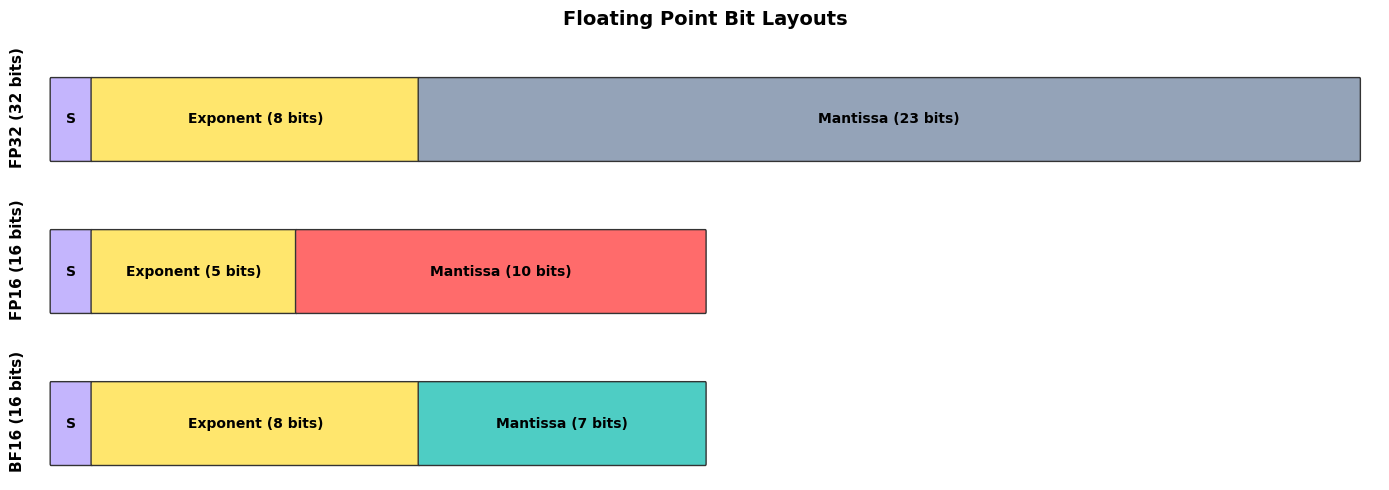

Key: more exponent bits = larger range, more mantissa bits = more precision
BF16 has FP32's range (8-bit exponent) but coarser precision (7-bit mantissa)


In [3]:
# Visualize the bit layout of each format
fig, axes = plt.subplots(3, 1, figsize=(14, 5))

formats = [
    ('FP32 (32 bits)', 1, 8, 23, '#94A3B8'),
    ('FP16 (16 bits)', 1, 5, 10, '#FF6B6B'),
    ('BF16 (16 bits)', 1, 8, 7, '#4ECDC4'),
]

for ax, (name, sign_bits, exp_bits, mant_bits, color) in zip(axes, formats):
    total = sign_bits + exp_bits + mant_bits
    x = 0

    # Sign bit
    rect = mpatches.FancyBboxPatch((x, 0), sign_bits, 1, boxstyle='round,pad=0.02',
                                    facecolor='#C4B5FD', edgecolor='#333')
    ax.add_patch(rect)
    ax.text(x + sign_bits/2, 0.5, 'S', ha='center', va='center', fontweight='bold', fontsize=10)
    x += sign_bits

    # Exponent
    rect = mpatches.FancyBboxPatch((x, 0), exp_bits, 1, boxstyle='round,pad=0.02',
                                    facecolor='#FFE66D', edgecolor='#333')
    ax.add_patch(rect)
    ax.text(x + exp_bits/2, 0.5, f'Exponent ({exp_bits} bits)', ha='center', va='center',
            fontweight='bold', fontsize=10)
    x += exp_bits

    # Mantissa
    rect = mpatches.FancyBboxPatch((x, 0), mant_bits, 1, boxstyle='round,pad=0.02',
                                    facecolor=color, edgecolor='#333')
    ax.add_patch(rect)
    ax.text(x + mant_bits/2, 0.5, f'Mantissa ({mant_bits} bits)', ha='center', va='center',
            fontweight='bold', fontsize=10)

    ax.set_xlim(-0.5, 32.5)
    ax.set_ylim(-0.2, 1.5)
    ax.set_ylabel(name, fontsize=11, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

axes[0].set_title('Floating Point Bit Layouts', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

print('Key: more exponent bits = larger range, more mantissa bits = more precision')
print('BF16 has FP32\'s range (8-bit exponent) but coarser precision (7-bit mantissa)')

In [4]:
# Demonstrate the practical differences
print('=== Range comparison ===')
for name, dtype in [('FP32', torch.float32), ('FP16', torch.float16), ('BF16', torch.bfloat16)]:
    info = torch.finfo(dtype)
    print(f'{name}: max={info.max:.2e}, min_positive={info.tiny:.2e}, eps={info.eps:.2e}')

print('\n=== Precision comparison ===')
val = torch.tensor(1.0001, dtype=torch.float32)
print(f'Original (FP32): {val.item():.10f}')
print(f'Cast to FP16:    {val.half().item():.10f}')
print(f'Cast to BF16:    {val.bfloat16().item():.10f}')

print('\n=== Overflow comparison ===')
big = torch.tensor(70000.0, dtype=torch.float32)
print(f'70000 in FP32: {big.item()}')
print(f'70000 in FP16: {big.half().item()}  ← overflows to inf!')
print(f'70000 in BF16: {big.bfloat16().item()}  ← fine, same range as FP32')

print('\n=== Gradient underflow ===')
tiny = torch.tensor(1e-8, dtype=torch.float32)
print(f'1e-8 in FP32: {tiny.item()}')
print(f'1e-8 in FP16: {tiny.half().item()}  ← rounds to 0! Gradient vanishes!')
print(f'1e-8 in BF16: {tiny.bfloat16().item()}  ← preserved')

=== Range comparison ===
FP32: max=3.40e+38, min_positive=1.18e-38, eps=1.19e-07
FP16: max=6.55e+04, min_positive=6.10e-05, eps=9.77e-04
BF16: max=3.39e+38, min_positive=1.18e-38, eps=7.81e-03

=== Precision comparison ===
Original (FP32): 1.0001000166
Cast to FP16:    1.0000000000
Cast to BF16:    1.0000000000

=== Overflow comparison ===
70000 in FP32: 70000.0
70000 in FP16: inf  ← overflows to inf!
70000 in BF16: 70144.0  ← fine, same range as FP32

=== Gradient underflow ===
1e-8 in FP32: 9.99999993922529e-09
1e-8 in FP16: 0.0  ← rounds to 0! Gradient vanishes!
1e-8 in BF16: 1.0011717677116394e-08  ← preserved


## 2. Why "Mixed" Precision?

Not everything can run in half precision. The "mixed" means:

- **Forward/backward pass**: FP16 or BF16 (fast, on tensor cores)
- **Master weights**: FP32 (full precision copy for accurate updates)
- **Loss computation**: FP32 (numerical stability in softmax/cross-entropy)
- **Optimizer state**: FP32 (AdamW's momentum and variance need precision)

PyTorch's `torch.amp.autocast` handles this automatically — it picks
the right precision for each operation.

From `trainer.py:70-71`:
```python
self.use_amp = config.dtype != "float32" and self.device.type == "cuda"
self.scaler = torch.amp.GradScaler("cuda", enabled=self.use_amp and config.dtype == "float16")
```

In [5]:
# Show which operations autocast handles in which precision
ops_table = [
    ('Matrix multiply (Linear, Attention)', 'FP16/BF16', 'This is where tensor cores give 2x speedup'),
    ('Convolutions', 'FP16/BF16', 'Also uses tensor cores'),
    ('Softmax', 'FP32', 'Exponentials overflow easily in FP16'),
    ('Cross-entropy loss', 'FP32', 'Log of small probabilities needs precision'),
    ('Layer norm / RMSNorm', 'FP32', 'Variance computation needs precision'),
    ('Optimizer (AdamW)', 'FP32', 'Momentum/variance accumulate tiny updates'),
    ('Master weights', 'FP32', 'Small LR × gradient must not round to zero'),
]

print(f'{"Operation":<40} {"Precision":<12} {"Why"}')
print('=' * 100)
for op, prec, why in ops_table:
    color = '✅' if 'FP16' in prec else '🔒'
    print(f'{color} {op:<38} {prec:<12} {why}')

print('\n✅ = accelerated by tensor cores  🔒 = needs full precision for correctness')

Operation                                Precision    Why
✅ Matrix multiply (Linear, Attention)    FP16/BF16    This is where tensor cores give 2x speedup
✅ Convolutions                           FP16/BF16    Also uses tensor cores
🔒 Softmax                                FP32         Exponentials overflow easily in FP16
🔒 Cross-entropy loss                     FP32         Log of small probabilities needs precision
🔒 Layer norm / RMSNorm                   FP32         Variance computation needs precision
🔒 Optimizer (AdamW)                      FP32         Momentum/variance accumulate tiny updates
🔒 Master weights                         FP32         Small LR × gradient must not round to zero

✅ = accelerated by tensor cores  🔒 = needs full precision for correctness


## 3. Loss Scaling (FP16 only)

FP16 can represent values down to ~6×10⁻⁸. Gradients are often smaller than this,
so they **underflow to zero** and the model stops learning.

**Loss scaling** fixes this: multiply the loss by a large factor (e.g., 1024) before
`.backward()`, which scales all gradients up into FP16's representable range.
Then divide by the same factor before the optimizer step.

PyTorch's `GradScaler` does this automatically and dynamically adjusts the scale
factor — increasing it when safe, decreasing when overflow occurs.

**BF16 doesn't need loss scaling** because it has the same exponent range as FP32.
This is why BF16 is preferred when available (A100, H100, Apple M-series).

In [6]:
# Demonstrate loss scaling
print('=== Without loss scaling (FP16) ===')
gradients_fp32 = torch.tensor([1e-6, 5e-7, 1e-8, 3e-9], dtype=torch.float32)
print(f'Gradients in FP32: {gradients_fp32.tolist()}')
print(f'Cast to FP16:      {gradients_fp32.half().tolist()}')
print(f'Lost to underflow: {(gradients_fp32.half() == 0).sum().item()}/{len(gradients_fp32)} gradients!\n')

print('=== With loss scaling (scale=1024) ===')
scale_factor = 1024.0
scaled = gradients_fp32 * scale_factor
print(f'Scaled gradients:  {scaled.tolist()}')
print(f'Cast to FP16:      {scaled.half().tolist()}')
print(f'Unscale (÷{scale_factor:.0f}):  {(scaled.half().float() / scale_factor).tolist()}')
print(f'Lost to underflow: {(scaled.half() == 0).sum().item()}/{len(gradients_fp32)} gradients!\n')

print('=== BF16 (no scaling needed) ===')
print(f'Gradients in BF16: {gradients_fp32.bfloat16().tolist()}')
print(f'Lost to underflow: {(gradients_fp32.bfloat16() == 0).sum().item()}/{len(gradients_fp32)} gradients!')

=== Without loss scaling (FP16) ===
Gradients in FP32: [9.999999974752427e-07, 4.999999987376214e-07, 9.99999993922529e-09, 3.000000026176508e-09]
Cast to FP16:      [1.0132789611816406e-06, 4.76837158203125e-07, 0.0, 0.0]
Lost to underflow: 2/4 gradients!

=== With loss scaling (scale=1024) ===
Scaled gradients:  [0.0010239999974146485, 0.0005119999987073243, 1.0239999937766697e-05, 3.0720000268047443e-06]
Cast to FP16:      [0.0010242462158203125, 0.0005121231079101562, 1.0251998901367188e-05, 3.0994415283203125e-06]
Unscale (÷1024):  [1.000240445137024e-06, 5.00120222568512e-07, 1.0011717677116394e-08, 3.026798367500305e-09]
Lost to underflow: 0/4 gradients!

=== BF16 (no scaling needed) ===
Gradients in BF16: [9.98377799987793e-07, 4.991888999938965e-07, 1.0011717677116394e-08, 2.9976945370435715e-09]
Lost to underflow: 0/4 gradients!


## 4. Memory Savings

Half precision halves the memory for model weights and activations.
This means you can either:
- **Double your batch size** (more throughput)
- **Train a larger model** (more capability)
- **Use longer sequences** (more context)

Model                      Params    FP32 (MB)   FP16/BF16 (MB)    Savings
TINY (256d, 6L)            19.9M       76.0MB           38.0MB      2.0x
SMALL (768d, 12L)         107.0M      408.1MB          204.0MB      2.0x
MEDIUM (1024d, 24L)       265.3M     1012.2MB          506.1MB      2.0x


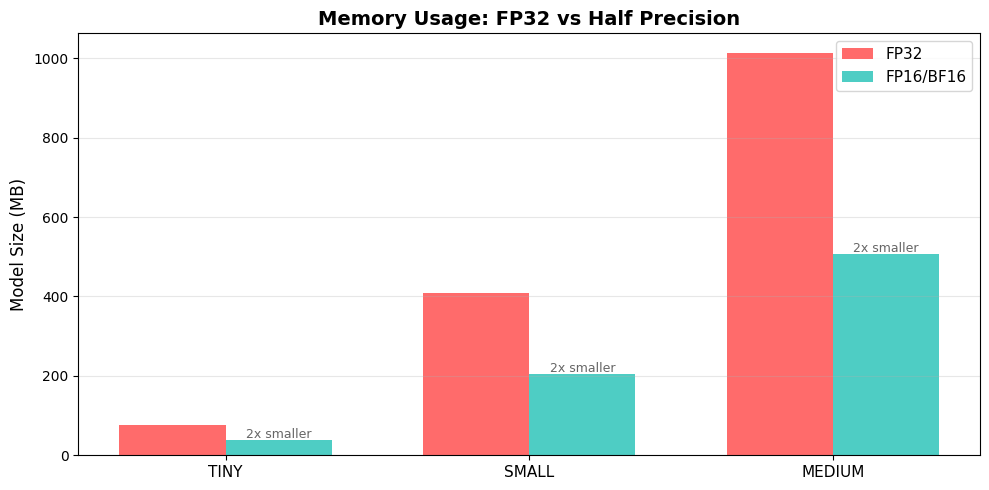


Note: training memory is ~4x model size (weights + gradients + optimizer state).
Mixed precision reduces weights and activations, but optimizer state stays FP32.


In [7]:
from ai_playground.models import TransformerConfig

configs = [
    ('TINY (256d, 6L)', TransformerConfig(dim=256, n_layers=6, n_heads=8, n_kv_heads=4)),
    ('SMALL (768d, 12L)', TransformerConfig(dim=768, n_layers=12, n_heads=12, n_kv_heads=4)),
    ('MEDIUM (1024d, 24L)', TransformerConfig(dim=1024, n_layers=24, n_heads=16, n_kv_heads=4)),
]

print(f'{"Model":<22} {"Params":>10} {"FP32 (MB)":>12} {"FP16/BF16 (MB)":>16} {"Savings":>10}')
print('=' * 75)

sizes_fp32 = []
sizes_fp16 = []
labels = []

for name, cfg in configs:
    n_params = cfg.num_params()
    fp32_mb = n_params * 4 / 1024**2
    fp16_mb = n_params * 2 / 1024**2
    print(f'{name:<22} {n_params/1e6:>8.1f}M {fp32_mb:>10.1f}MB {fp16_mb:>14.1f}MB {fp32_mb/fp16_mb:>8.1f}x')
    sizes_fp32.append(fp32_mb)
    sizes_fp16.append(fp16_mb)
    labels.append(name.split('(')[0].strip())

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(labels))
w = 0.35
ax.bar(x - w/2, sizes_fp32, w, label='FP32', color='#FF6B6B')
ax.bar(x + w/2, sizes_fp16, w, label='FP16/BF16', color='#4ECDC4')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Model Size (MB)', fontsize=12)
ax.set_title('Memory Usage: FP32 vs Half Precision', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

for i, (f32, f16) in enumerate(zip(sizes_fp32, sizes_fp16)):
    ax.text(i + w/2, f16 + 5, f'2x smaller', ha='center', fontsize=9, color='#666')

plt.tight_layout()
plt.show()

print('\nNote: training memory is ~4x model size (weights + gradients + optimizer state).')
print('Mixed precision reduces weights and activations, but optimizer state stays FP32.')

## 5. Training Comparison: FP32 vs BF16

Let's train the same model with both precisions and compare loss curves.
On CPU we won't see a speed difference (no tensor cores), but we can
verify that BF16 achieves the same final loss.

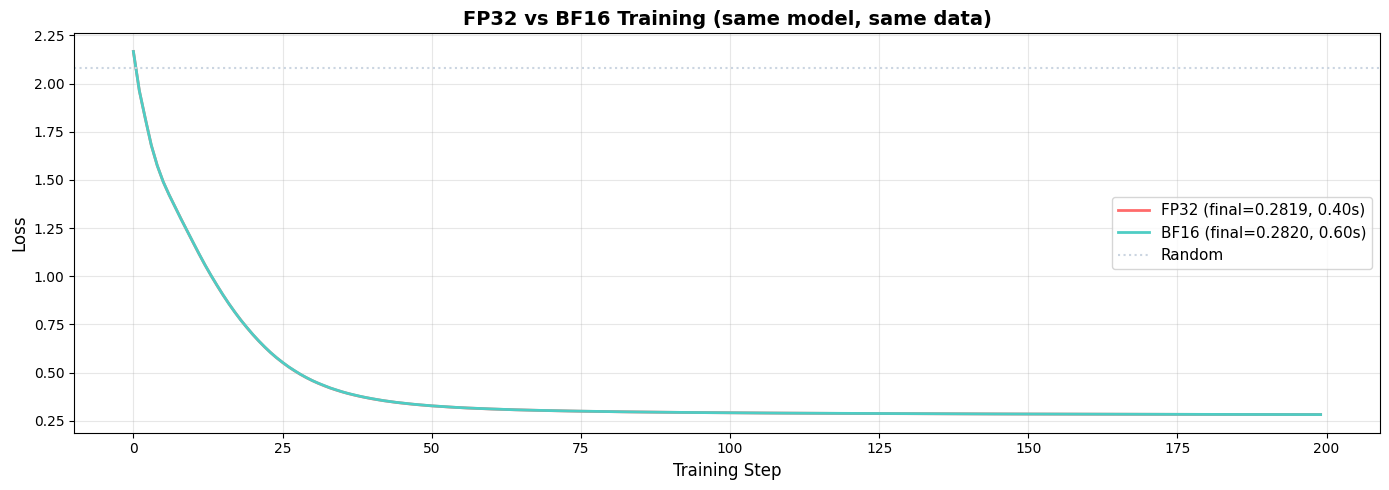

Final loss — FP32: 0.2819, BF16: 0.2820
Difference: 0.0001 (should be very small)

On GPU with tensor cores, BF16 would be ~2x faster.
On CPU there's no speedup (no tensor cores), but the results match.


In [8]:
from ai_playground.models import Transformer, TransformerConfig

VOCAB = ['<pad>', 'the', 'cat', 'dog', 'sat', 'ran', 'on', 'mat']
tok2id = {t: i for i, t in enumerate(VOCAB)}
sentences = ['the cat sat on the mat', 'the dog ran on the mat',
             'the cat ran on the mat', 'the dog sat on the mat']
all_tok = [[tok2id[w] for w in s.split()] for s in sentences]
train_x = torch.tensor([t[:-1] for t in all_tok])
train_y = torch.tensor([t[1:] for t in all_tok])

def train_precision(dtype_name, n_steps=200, seed=42):
    """Train with a specific precision and return loss history + timing."""
    torch.manual_seed(seed)
    cfg = TransformerConfig(
        vocab_size=len(VOCAB), dim=32, n_layers=2, n_heads=4,
        n_kv_heads=2, max_seq_len=16, ffn_dim_multiplier=2.0,
    )
    model = Transformer(cfg)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)
    
    dtype_map = {'float32': torch.float32, 'bfloat16': torch.bfloat16}
    amp_dtype = dtype_map[dtype_name]
    use_amp = dtype_name != 'float32'
    
    losses = []
    model.train()
    import time
    t0 = time.perf_counter()
    
    for step in range(n_steps):
        with torch.amp.autocast('cpu', dtype=amp_dtype, enabled=use_amp):
            logits = model(train_x)
            loss = F.cross_entropy(logits.view(-1, len(VOCAB)), train_y.view(-1))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    
    elapsed = time.perf_counter() - t0
    return losses, elapsed

# Train both
losses_fp32, time_fp32 = train_precision('float32')
losses_bf16, time_bf16 = train_precision('bfloat16')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(losses_fp32, label=f'FP32 (final={losses_fp32[-1]:.4f}, {time_fp32:.2f}s)', color='#FF6B6B', linewidth=2)
ax.plot(losses_bf16, label=f'BF16 (final={losses_bf16[-1]:.4f}, {time_bf16:.2f}s)', color='#4ECDC4', linewidth=2)
ax.axhline(y=np.log(len(VOCAB)), color='#CBD5E1', linestyle=':', label='Random')
ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('FP32 vs BF16 Training (same model, same data)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final loss — FP32: {losses_fp32[-1]:.4f}, BF16: {losses_bf16[-1]:.4f}')
print(f'Difference: {abs(losses_fp32[-1] - losses_bf16[-1]):.4f} (should be very small)')
print(f'\nOn GPU with tensor cores, BF16 would be ~2x faster.')
print(f'On CPU there\'s no speedup (no tensor cores), but the results match.')

## Key Takeaways

1. **Mixed precision = 2x speedup** on modern GPUs with near-zero quality loss.
2. **BF16 > FP16** for training because it has FP32's range (no loss scaling needed). Use BF16 when your GPU supports it (A100+, Apple M-series).
3. **"Mixed" means** compute in half precision, accumulate in full precision. PyTorch's `autocast` and `GradScaler` handle this transparently.
4. **Memory savings** are ~2x for model weights and activations — enables larger batches or bigger models.
5. **The trainer** (`trainer.py:69-76`) supports FP32, FP16 (with GradScaler), and BF16 via the `dtype` config field.

### References
- [Mixed Precision Training](https://arxiv.org/abs/1710.03740) (Micikevicius et al., 2018)
- [PyTorch AMP docs](https://pytorch.org/docs/stable/amp.html)
- [docs/PAPERS.md § Training Optimization](../../docs/PAPERS.md#training-optimization)

### Next: `03_gradient_accumulation.ipynb` — simulate large batches on small hardware